arena,total_partidas,jogos,vitorias_mandante,taxa_vitoria_mandante
Maracanã,631,631,324,0.513
Mineirão,459,459,246,0.536
Morumbi,413,413,229,0.554
Couto Pereira,295,295,140,0.475
Serra Dourada,235,235,115,0.489
Orlando Scarpelli,219,219,95,0.434
Pacaembu,213,213,116,0.545
Estádio Raimundo Sampaio,201,201,101,0.502
Beira Rio,200,200,117,0.585
Vila Belmiro,192,192,105,0.547


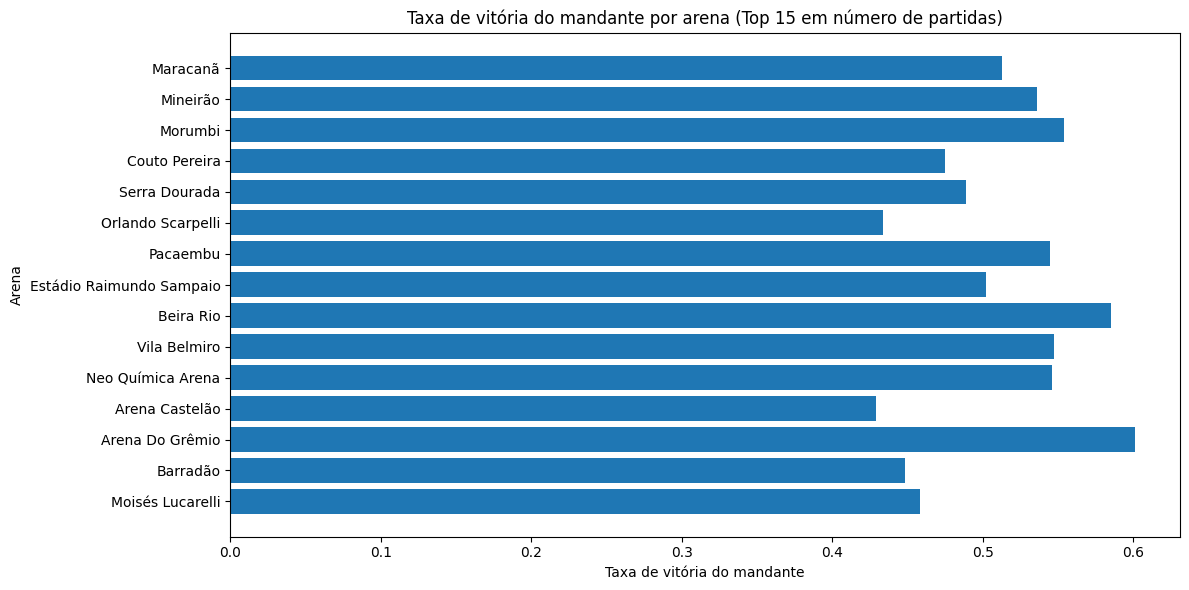

In [0]:
# =========================================================
# Análise: Arenas com mais partidas e desempenho dos clubes
# Pergunta: Quais arenas receberam mais partidas e como os clubes performam nelas?
# =========================================================

import matplotlib.pyplot as plt

query = """
WITH partidas_por_arena AS (
    SELECT
        arena,
        COUNT(*) AS total_partidas
    FROM fato_partida
    GROUP BY arena
),

desempenho_mandante AS (
    SELECT
        arena,
        COUNT(*) AS jogos,
        SUM(CASE WHEN mandante_placar > visitante_placar THEN 1 ELSE 0 END) AS vitorias_mandante,
        CAST(SUM(CASE WHEN mandante_placar > visitante_placar THEN 1 ELSE 0 END) AS DOUBLE)
        / CAST(COUNT(*) AS DOUBLE) AS taxa_vitoria_mandante
    FROM fato_partida
    GROUP BY arena
)

SELECT
    p.arena,
    p.total_partidas,
    d.jogos,
    d.vitorias_mandante,
    ROUND(d.taxa_vitoria_mandante, 3) AS taxa_vitoria_mandante
FROM partidas_por_arena p
JOIN desempenho_mandante d
    ON p.arena = d.arena
ORDER BY p.total_partidas DESC
"""

# Executa a consulta
df = spark.sql(query)

# Exibe tabela (fica salva no .ipynb)
display(df)

# =========================================================
# Gráfico de apoio: Taxa de vitória do mandante por arena
# (limitado às arenas com maior volume de partidas)
# =========================================================

# Converte para Pandas para plotagem
pdf = df.limit(15).toPandas()

plt.figure(figsize=(12, 6))
plt.barh(pdf["arena"], pdf["taxa_vitoria_mandante"])
plt.xlabel("Taxa de vitória do mandante")
plt.ylabel("Arena")
plt.title("Taxa de vitória do mandante por arena (Top 15 em número de partidas)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
